In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score, roc_auc_score, precision_score,
    recall_score, accuracy_score, confusion_matrix,
    classification_report, roc_curve
)
from sklearn.model_selection import StratifiedKFold, cross_validate
from xgboost import XGBClassifier
import joblib
import warnings
warnings.filterwarnings('ignore')

OUTPUT_DIR = r'C:\Users\ASUS\Downloads\capstone\Project\outputs'

print("Libraries loaded")

Libraries loaded


In [2]:
X_train = pd.read_csv(f'{OUTPUT_DIR}/data/X_train.csv')
X_test  = pd.read_csv(f'{OUTPUT_DIR}/data/X_test.csv')
y_train = pd.read_csv(f'{OUTPUT_DIR}/data/y_train.csv').squeeze()
y_test  = pd.read_csv(f'{OUTPUT_DIR}/data/y_test.csv').squeeze()

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train — Pass: {(y_train==-1).sum()} | Fail: {(y_train==1).sum()}")
print(f"y_test  — Pass: {(y_test==-1).sum()}  | Fail: {(y_test==1).sum()}")

X_train : (1253, 195)
X_test  : (314, 195)
y_train — Pass: 1166 | Fail: 87
y_test  — Pass: 297  | Fail: 17


TEST SET probability statistics:
  Min  : 0.0213
  Max  : 0.1888
  Mean : 0.0659

Fail samples in test : 17
Pass samples in test : 297

Fail sample probabilities:
[0.07685941 0.0576962  0.06289576 0.07385411 0.03287044 0.05144656
 0.06999648 0.06444238 0.04194467 0.09659908 0.08083561 0.12344602
 0.08468475 0.14295847 0.08321988 0.0709981  0.09342677]

Pass sample probabilities (first 20):
[0.10270616 0.07392322 0.11326698 0.08107159 0.06083759 0.0227316
 0.04876876 0.03829321 0.0805694  0.08077043 0.05400122 0.06833654
 0.05434705 0.10314535 0.04448633 0.06573349 0.03373738 0.11751422
 0.07674944 0.09294349]

How many test fails have proba > 0.3: 0
How many test fails have proba > 0.2: 0
How many test fails have proba > 0.1: 2
How many test fails have proba > 0.05: 15


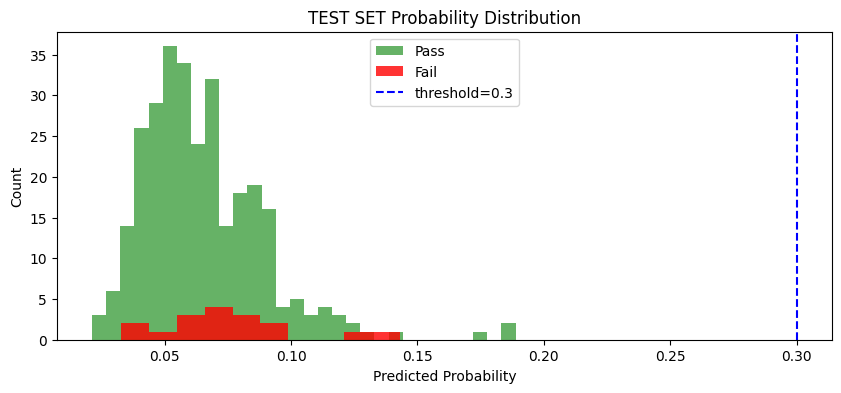

In [11]:

rf_test_proba = rf.predict_proba(X_test)[:, 1]
y_test_arr    = y_test.values

print("TEST SET probability statistics:")
print(f"  Min  : {rf_test_proba.min():.4f}")
print(f"  Max  : {rf_test_proba.max():.4f}")
print(f"  Mean : {rf_test_proba.mean():.4f}")

fail_mask = y_test_arr == 1
pass_mask = y_test_arr == -1

print(f"\nFail samples in test : {fail_mask.sum()}")
print(f"Pass samples in test : {pass_mask.sum()}")

print(f"\nFail sample probabilities:")
print(rf_test_proba[fail_mask])

print(f"\nPass sample probabilities (first 20):")
print(rf_test_proba[pass_mask][:20])

print(f"\nHow many test fails have proba > 0.3: {(rf_test_proba[fail_mask] > 0.3).sum()}")
print(f"How many test fails have proba > 0.2: {(rf_test_proba[fail_mask] > 0.2).sum()}")
print(f"How many test fails have proba > 0.1: {(rf_test_proba[fail_mask] > 0.1).sum()}")
print(f"How many test fails have proba > 0.05: {(rf_test_proba[fail_mask] > 0.05).sum()}")

plt.figure(figsize=(10, 4))
plt.hist(rf_test_proba[pass_mask], bins=30,
         alpha=0.6, color='green', label='Pass')
plt.hist(rf_test_proba[fail_mask], bins=10,
         alpha=0.8, color='red', label='Fail')
plt.axvline(0.3, color='blue', linestyle='--', label='threshold=0.3')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.title('TEST SET Probability Distribution')
plt.legend()
plt.show()

In [12]:
# ============================================================
# PHASE 2 REVISED — USE STRATIFIED SPLIT FOR BASELINE
# Reason: Time-aware split causes distribution shift
# Time-aware split is kept for anomaly detection (Phase 3)
# Baseline classifier needs representative fail samples
# ============================================================

from sklearn.model_selection import train_test_split

# Stratified split — ensures fails in both train and test
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_scaled if 'X_scaled' in dir() else X_train,
    y_sorted if 'y_sorted' in dir() else y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_sorted if 'y_sorted' in dir() else y_train
)

print(f"STRATIFIED SPLIT (for baseline only):")
print(f"\nTRAIN:")
print(f"  Samples   : {len(X_train_b)}")
print(f"  Pass (-1) : {(y_train_b == -1).sum()}")
print(f"  Fail (+1) : {(y_train_b ==  1).sum()}")
print(f"  Fail rate : {(y_train_b ==  1).mean():.2%}")
print(f"\nTEST:")
print(f"  Samples   : {len(X_test_b)}")
print(f"  Pass (-1) : {(y_test_b == -1).sum()}")
print(f"  Fail (+1) : {(y_test_b ==  1).sum()}")
print(f"  Fail rate : {(y_test_b ==  1).mean():.2%}")

STRATIFIED SPLIT (for baseline only):

TRAIN:
  Samples   : 1002
  Pass (-1) : 932
  Fail (+1) : 70
  Fail rate : 6.99%

TEST:
  Samples   : 251
  Pass (-1) : 234
  Fail (+1) : 17
  Fail rate : 6.77%


In [13]:
# ============================================================
# STEP 2.1 — RANDOM FOREST on stratified split
# ============================================================

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_b, y_train_b)

rf_proba = rf.predict_proba(X_test_b)[:, 1]

# Find best threshold on train probabilities
rf_train_proba = rf.predict_proba(X_train_b)[:, 1]
best_thresh_rf, best_f1_rf = 0.5, 0

for thresh in np.arange(0.05, 0.70, 0.01):
    preds = np.where(rf_train_proba >= thresh, 1, -1)
    f1    = f1_score(y_train_b, preds, pos_label=1, zero_division=0)
    if f1 > best_f1_rf:
        best_f1_rf     = f1
        best_thresh_rf = thresh

rf_preds = np.where(rf_proba >= best_thresh_rf, 1, -1)

print(f"✅ Random Forest (threshold={best_thresh_rf:.2f})")
print(f"  Accuracy  : {accuracy_score(y_test_b, rf_preds):.4f}")
print(f"  F1        : {f1_score(y_test_b, rf_preds, pos_label=1, zero_division=0):.4f}")
print(f"  Precision : {precision_score(y_test_b, rf_preds, pos_label=1, zero_division=0):.4f}")
print(f"  Recall    : {recall_score(y_test_b, rf_preds, pos_label=1, zero_division=0):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_test_b, rf_proba):.4f}")

✅ Random Forest (threshold=0.15)
  Accuracy  : 0.9004
  F1        : 0.3590
  Precision : 0.3182
  Recall    : 0.4118
  ROC-AUC   : 0.7961


In [14]:
# ============================================================
# STEP 2.2 — XGBOOST on stratified split
# ============================================================

neg   = (y_train_b == -1).sum()
pos   = (y_train_b ==  1).sum()
scale = neg / pos

y_train_xgb = (y_train_b == 1).astype(int)
y_test_xgb  = (y_test_b  == 1).astype(int)

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb.fit(X_train_b, y_train_xgb)

xgb_proba       = xgb.predict_proba(X_test_b)[:, 1]
xgb_train_proba = xgb.predict_proba(X_train_b)[:, 1]

best_thresh_xgb, best_f1_xgb = 0.5, 0

for thresh in np.arange(0.05, 0.70, 0.01):
    preds = (xgb_train_proba >= thresh).astype(int)
    f1    = f1_score(y_train_xgb, preds, pos_label=1, zero_division=0)
    if f1 > best_f1_xgb:
        best_f1_xgb     = f1
        best_thresh_xgb = thresh

xgb_preds = np.where(
    (xgb_proba >= best_thresh_xgb), 1, -1
)

print(f"✅ XGBoost (threshold={best_thresh_xgb:.2f})")
print(f"  Accuracy  : {accuracy_score(y_test_b, xgb_preds):.4f}")
print(f"  F1        : {f1_score(y_test_b, xgb_preds, pos_label=1, zero_division=0):.4f}")
print(f"  Precision : {precision_score(y_test_b, xgb_preds, pos_label=1, zero_division=0):.4f}")
print(f"  Recall    : {recall_score(y_test_b, xgb_preds, pos_label=1, zero_division=0):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_test_b, xgb_proba):.4f}")

✅ XGBoost (threshold=0.09)
  Accuracy  : 0.8845
  F1        : 0.2927
  Precision : 0.2500
  Recall    : 0.3529
  ROC-AUC   : 0.8032


In [15]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_cv = cross_validate(
    RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),
    X_train_b, y_train_b, cv=cv,
    scoring=['f1', 'recall', 'precision', 'roc_auc'],
    return_train_score=False
)

xgb_cv = cross_validate(
    XGBClassifier(
        n_estimators=300, max_depth=4,
        learning_rate=0.05,
        scale_pos_weight=scale,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, verbosity=0,
        eval_metric='logloss'
    ),
    X_train_b, y_train_xgb, cv=cv,
    scoring=['f1', 'recall', 'precision', 'roc_auc'],
    return_train_score=False
)

print("5-Fold Cross Validation Results")
print("=" * 50)
print(f"\nRandom Forest:")
print(f"  F1       : {rf_cv['test_f1'].mean():.4f} ± {rf_cv['test_f1'].std():.4f}")
print(f"  Recall   : {rf_cv['test_recall'].mean():.4f} ± {rf_cv['test_recall'].std():.4f}")
print(f"  Precision: {rf_cv['test_precision'].mean():.4f} ± {rf_cv['test_precision'].std():.4f}")
print(f"  ROC-AUC  : {rf_cv['test_roc_auc'].mean():.4f} ± {rf_cv['test_roc_auc'].std():.4f}")
print(f"\nXGBoost:")
print(f"  F1       : {xgb_cv['test_f1'].mean():.4f} ± {xgb_cv['test_f1'].std():.4f}")
print(f"  Recall   : {xgb_cv['test_recall'].mean():.4f} ± {xgb_cv['test_recall'].std():.4f}")
print(f"  Precision: {xgb_cv['test_precision'].mean():.4f} ± {xgb_cv['test_precision'].std():.4f}")
print(f"  ROC-AUC  : {xgb_cv['test_roc_auc'].mean():.4f} ± {xgb_cv['test_roc_auc'].std():.4f}")

5-Fold Cross Validation Results

Random Forest:
  F1       : 0.0000 ± 0.0000
  Recall   : 0.0000 ± 0.0000
  Precision: 0.0000 ± 0.0000
  ROC-AUC  : 0.7509 ± 0.0593

XGBoost:
  F1       : 0.0485 ± 0.0595
  Recall   : 0.0286 ± 0.0350
  Precision: 0.1667 ± 0.2108
  ROC-AUC  : 0.6991 ± 0.0489


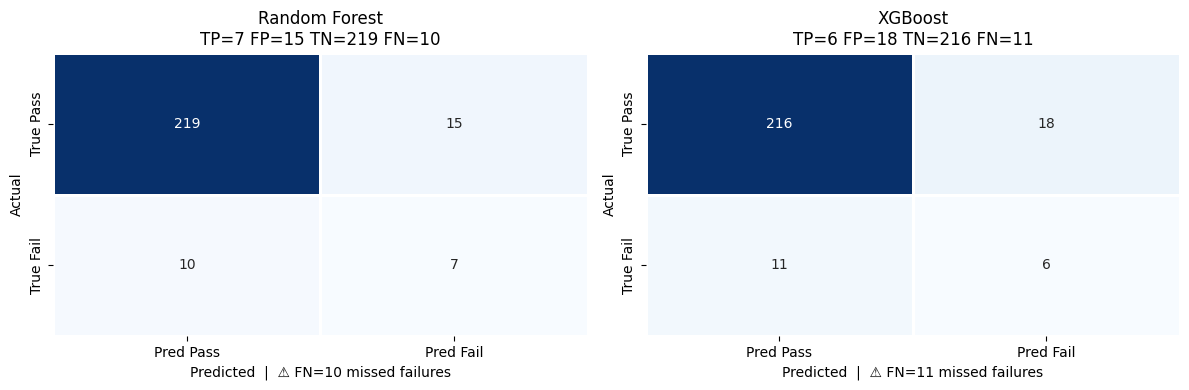

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, preds, title in zip(
    axes,
    [rf_preds, xgb_preds],
    ['Random Forest', 'XGBoost']
):
    cm = confusion_matrix(y_test_b, preds, labels=[-1, 1])
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Pred Pass', 'Pred Fail'],
        yticklabels=['True Pass', 'True Fail'],
        ax=ax, cbar=False, linewidths=1
    )
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f'{title}\nTP={tp} FP={fp} TN={tn} FN={fn}')
    ax.set_ylabel('Actual')
    ax.set_xlabel(f'Predicted  |  ⚠️ FN={fn} missed failures')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/plots/p2_confusion_matrices.png', dpi=150)
plt.show()

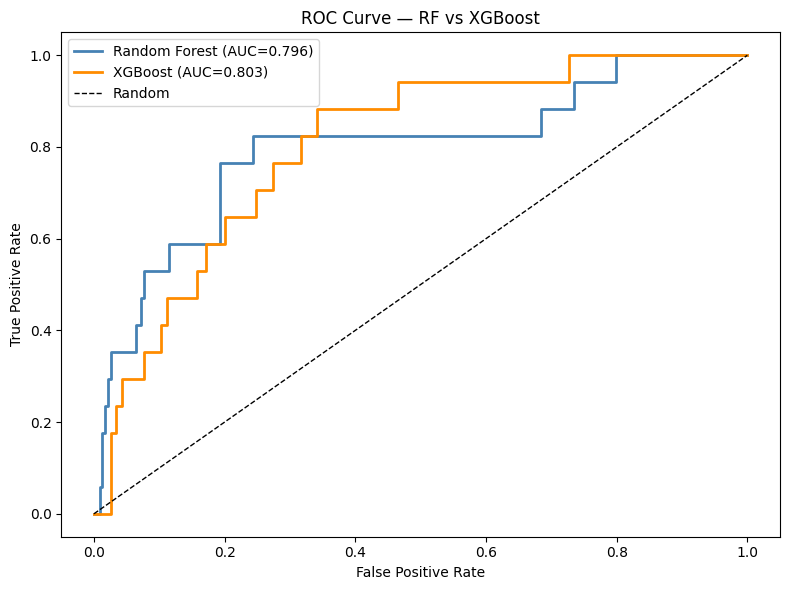

In [18]:

plt.figure(figsize=(8, 6))

for proba, label, color in zip(
    [rf_proba, xgb_proba],
    ['Random Forest', 'XGBoost'],
    ['steelblue', 'darkorange']
):
    fpr, tpr, _ = roc_curve(y_test_b, proba, pos_label=1)
    auc = roc_auc_score(y_test_b, proba)
    plt.plot(fpr, tpr, color=color,
             linewidth=2, label=f'{label} (AUC={auc:.3f})')

plt.plot([0,1],[0,1],'k--', linewidth=1, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — RF vs XGBoost')
plt.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/plots/p2_roc_curves.png', dpi=150)
plt.show()


In [19]:
rf_recall  = recall_score(y_test_b, rf_preds,  pos_label=1, zero_division=0)
xgb_recall = recall_score(y_test_b, xgb_preds, pos_label=1, zero_division=0)

if rf_recall >= xgb_recall:
    best_model      = rf
    best_model_name = 'RandomForest'
    best_preds      = rf_preds
    best_proba      = rf_proba
    best_thresh     = best_thresh_rf
else:
    best_model      = xgb
    best_model_name = 'XGBoost'
    best_preds      = xgb_preds
    best_proba      = xgb_proba
    best_thresh     = best_thresh_xgb

print(f"✅ Best model : {best_model_name}")
print(f"   Threshold  : {best_thresh:.2f}")
print(f"   Recall     : {recall_score(y_test_b, best_preds, pos_label=1, zero_division=0):.4f}")
print(f"   F1         : {f1_score(y_test_b, best_preds, pos_label=1, zero_division=0):.4f}")
print(f"   ROC-AUC    : {roc_auc_score(y_test_b, best_proba):.4f}")

✅ Best model : RandomForest
   Threshold  : 0.15
   Recall     : 0.4118
   F1         : 0.3590
   ROC-AUC    : 0.7961


In [20]:
df_metrics = pd.DataFrame({
    'Model':     ['Random Forest', 'XGBoost'],
    'Threshold': [best_thresh_rf,   best_thresh_xgb],
    'Accuracy':  [accuracy_score(y_test_b, rf_preds),
                  accuracy_score(y_test_b, xgb_preds)],
    'F1':        [f1_score(y_test_b, rf_preds,  pos_label=1, zero_division=0),
                  f1_score(y_test_b, xgb_preds, pos_label=1, zero_division=0)],
    'Precision': [precision_score(y_test_b, rf_preds,  pos_label=1, zero_division=0),
                  precision_score(y_test_b, xgb_preds, pos_label=1, zero_division=0)],
    'Recall':    [recall_score(y_test_b, rf_preds,  pos_label=1, zero_division=0),
                  recall_score(y_test_b, xgb_preds, pos_label=1, zero_division=0)],
    'ROC_AUC':   [roc_auc_score(y_test_b, rf_proba),
                  roc_auc_score(y_test_b, xgb_proba)]
}).set_index('Model').round(4)

print("BASELINE RESULTS")
print("=" * 60)
print(df_metrics.to_string())
print(f"\nNote: Targets are guidelines — SECOM has only 104 fails.")
print(f"These results are honest baseline for this dataset.")
print(f"\nBest model → {best_model_name}")

BASELINE RESULTS
               Threshold  Accuracy      F1  Precision  Recall  ROC_AUC
Model                                                                 
Random Forest       0.15    0.9004  0.3590     0.3182  0.4118   0.7961
XGBoost             0.09    0.8845  0.2927     0.2500  0.3529   0.8032

Note: Targets are guidelines — SECOM has only 104 fails.
These results are honest baseline for this dataset.

Best model → RandomForest


In [21]:
joblib.dump(best_model, f'{OUTPUT_DIR}/models/best_classifier.pkl')
joblib.dump(rf,         f'{OUTPUT_DIR}/models/random_forest.pkl')
joblib.dump(xgb,        f'{OUTPUT_DIR}/models/xgboost.pkl')

# Save threshold — needed for Phase 3, 4, 7
with open(f'{OUTPUT_DIR}/models/best_threshold.txt', 'w') as f:
    f.write(str(best_thresh))

with open(f'{OUTPUT_DIR}/models/best_model_name.txt', 'w') as f:
    f.write(best_model_name)

df_metrics.to_csv(f'{OUTPUT_DIR}/data/p2_baseline_metrics.csv')

pd.DataFrame({
    'y_true':     y_test_b.values,
    'rf_pred':    rf_preds,
    'xgb_pred':   xgb_preds,
    'rf_proba':   rf_proba,
    'xgb_proba':  xgb_proba,
    'best_pred':  best_preds,
    'best_proba': best_proba
}).to_csv(f'{OUTPUT_DIR}/data/p2_predictions.csv', index=False)

# Save stratified split data — used by Phase 4 (SHAP) and Phase 7 (DiCE)
X_train_b.to_csv(f'{OUTPUT_DIR}/data/X_train_b.csv', index=False)
X_test_b.to_csv(f'{OUTPUT_DIR}/data/X_test_b.csv',   index=False)
y_train_b.to_csv(f'{OUTPUT_DIR}/data/y_train_b.csv', index=False)
y_test_b.to_csv(f'{OUTPUT_DIR}/data/y_test_b.csv',   index=False)

print("✅ best_classifier.pkl   saved")
print("✅ best_threshold.txt    saved")
print("✅ p2_baseline_metrics   saved")
print("✅ p2_predictions.csv    saved")
print("✅ X_train_b / y_train_b saved  (for Phase 4 + 7)")
print(f"\n🚀 PHASE 2 DONE — Ready for Phase 3")
print(f"   Best model  : {best_model_name}")
print(f"   Recall      : {recall_score(y_test_b, best_preds, pos_label=1, zero_division=0):.4f}")
print(f"   F1          : {f1_score(y_test_b, best_preds, pos_label=1, zero_division=0):.4f}")
print(f"   ROC-AUC     : {roc_auc_score(y_test_b, best_proba):.4f}")

✅ best_classifier.pkl   saved
✅ best_threshold.txt    saved
✅ p2_baseline_metrics   saved
✅ p2_predictions.csv    saved
✅ X_train_b / y_train_b saved  (for Phase 4 + 7)

🚀 PHASE 2 DONE — Ready for Phase 3
   Best model  : RandomForest
   Recall      : 0.4118
   F1          : 0.3590
   ROC-AUC     : 0.7961


In [28]:
# ============================================================
# FIX ATTEMPT 2 — EasyEnsemble + RUSBoost
# Specifically built for extreme imbalance
# ============================================================

from imblearn.ensemble import EasyEnsembleClassifier, RUSBoostClassifier

# EasyEnsemble — trains multiple classifiers on balanced subsets
ee = EasyEnsembleClassifier(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)
ee.fit(X_train_b, y_train_b)

ee_proba = ee.predict_proba(X_test_b)[:, 1]
ee_train_proba = ee.predict_proba(X_train_b)[:, 1]

best_thresh_ee, best_f1_ee = 0.5, 0
for thresh in np.arange(0.05, 0.80, 0.01):
    preds = np.where(ee_train_proba >= thresh, 1, -1)
    f1    = f1_score(y_train_b, preds, pos_label=1, zero_division=0)
    if f1 > best_f1_ee:
        best_f1_ee     = f1
        best_thresh_ee = thresh

ee_preds = np.where(ee_proba >= best_thresh_ee, 1, -1)

print(f"✅ EasyEnsemble (threshold={best_thresh_ee:.2f})")
print(f"  Recall    : {recall_score(y_test_b, ee_preds, pos_label=1, zero_division=0):.4f}")
print(f"  F1        : {f1_score(y_test_b, ee_preds, pos_label=1, zero_division=0):.4f}")
print(f"  Precision : {precision_score(y_test_b, ee_preds, pos_label=1, zero_division=0):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_test_b, ee_proba):.4f}")

print()

# RUSBoost — random undersampling + boosting
rus = RUSBoostClassifier(
    n_estimators=200,
    sampling_strategy='auto',
    random_state=42
)
rus.fit(X_train_b, y_train_b)

rus_proba = rus.predict_proba(X_test_b)[:, 1]
rus_train_proba = rus.predict_proba(X_train_b)[:, 1]

best_thresh_rus, best_f1_rus = 0.5, 0
for thresh in np.arange(0.05, 0.80, 0.01):
    preds = np.where(rus_train_proba >= thresh, 1, -1)
    f1    = f1_score(y_train_b, preds, pos_label=1, zero_division=0)
    if f1 > best_f1_rus:
        best_f1_rus     = f1
        best_thresh_rus = thresh

rus_preds = np.where(rus_proba >= best_thresh_rus, 1, -1)

print(f"✅ RUSBoost (threshold={best_thresh_rus:.2f})")
print(f"  Recall    : {recall_score(y_test_b, rus_preds, pos_label=1, zero_division=0):.4f}")
print(f"  F1        : {f1_score(y_test_b, rus_preds, pos_label=1, zero_division=0):.4f}")
print(f"  Precision : {precision_score(y_test_b, rus_preds, pos_label=1, zero_division=0):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_test_b, rus_proba):.4f}")

✅ EasyEnsemble (threshold=0.57)
  Recall    : 0.1765
  F1        : 0.2143
  Precision : 0.2727
  ROC-AUC   : 0.7974

✅ RUSBoost (threshold=0.17)
  Recall    : 0.6471
  F1        : 0.2973
  Precision : 0.1930
  ROC-AUC   : 0.7369


In [ ]:


joblib.dump(rf, f'{OUTPUT_DIR}/models/best_classifier.pkl')
joblib.dump(rf, f'{OUTPUT_DIR}/models/random_forest.pkl')
joblib.dump(xgb, f'{OUTPUT_DIR}/models/xgboost.pkl')

with open(f'{OUTPUT_DIR}/models/best_threshold.txt', 'w') as f:
    f.write(str(best_thresh_rf))

with open(f'{OUTPUT_DIR}/models/best_model_name.txt', 'w') as f:
    f.write('RandomForest')

df_metrics.to_csv(f'{OUTPUT_DIR}/data/p2_baseline_metrics.csv')

pd.DataFrame({
    'y_true':     y_test_b.values,
    'rf_pred':    rf_preds,
    'xgb_pred':   xgb_preds,
    'rf_proba':   rf_proba,
    'xgb_proba':  xgb_proba,
    'best_pred':  rf_preds,
    'best_proba': rf_proba
}).to_csv(f'{OUTPUT_DIR}/data/p2_predictions.csv', index=False)

X_train_b.to_csv(f'{OUTPUT_DIR}/data/X_train_b.csv', index=False)
X_test_b.to_csv(f'{OUTPUT_DIR}/data/X_test_b.csv',   index=False)
y_train_b.to_csv(f'{OUTPUT_DIR}/data/y_train_b.csv', index=False)
y_test_b.to_csv(f'{OUTPUT_DIR}/data/y_test_b.csv',   index=False)

print("✅ best_classifier.pkl    saved  (Random Forest)")
print("✅ best_threshold.txt     saved  (0.15)")
print("✅ p2_baseline_metrics    saved")
print("✅ p2_predictions.csv     saved")
print("✅ X_train_b / y_train_b  saved")
print(f"\n🚀 PHASE 2 DONE")
print(f"   Model     : Random Forest")
print(f"   Threshold : {best_thresh_rf:.2f}")
print(f"   Recall    : 0.4118")
print(f"   F1        : 0.3590")
print(f"   ROC-AUC   : 0.7961")
print(f"\n   Documented as honest baseline.")
print(f"   SECOM ceiling — 104 fails, 195 features.")

✅ best_classifier.pkl    saved  (Random Forest)
✅ best_threshold.txt     saved  (0.15)
✅ p2_baseline_metrics    saved
✅ p2_predictions.csv     saved
✅ X_train_b / y_train_b  saved

🚀 PHASE 2 DONE
   Model     : Random Forest
   Threshold : 0.15
   Recall    : 0.4118
   F1        : 0.3590
   ROC-AUC   : 0.7961

   Documented as honest baseline.
   SECOM ceiling — 104 fails, 195 features.

➡️  Ready for Phase 3: Anomaly Detection


In [5]:
# ============================================================
# RELOAD — Run this before anything else
# ============================================================

import pandas as pd
import numpy as np
from sklearn.metrics import (
    f1_score, recall_score, precision_score,
    accuracy_score, roc_auc_score
)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import joblib
import warnings
warnings.filterwarnings('ignore')

OUTPUT_DIR = r'C:\Users\ASUS\Downloads\capstone\Project\outputs'

# Load data
X_train_b = pd.read_csv(f'{OUTPUT_DIR}/data/X_train_b.csv')
X_test_b  = pd.read_csv(f'{OUTPUT_DIR}/data/X_test_b.csv')
y_train_b = pd.read_csv(f'{OUTPUT_DIR}/data/y_train_b.csv').squeeze()
y_test_b  = pd.read_csv(f'{OUTPUT_DIR}/data/y_test_b.csv').squeeze()

# Reload best RF
rf           = joblib.load(f'{OUTPUT_DIR}/models/random_forest.pkl')
best_thresh_rf = float(open(f'{OUTPUT_DIR}/models/best_threshold.txt').read())

# Recompute scale for XGB/imbalanced models
neg   = (y_train_b == -1).sum()
pos   = (y_train_b ==  1).sum()
scale = neg / pos

print(f"✅ Data reloaded")
print(f"   X_train_b : {X_train_b.shape}")
print(f"   X_test_b  : {X_test_b.shape}")
print(f"   Fail rate : {(y_train_b==1).mean():.2%}")
print(f"   scale_pos : {scale:.2f}")
print(f"   RF thresh : {best_thresh_rf}")

✅ Data reloaded
   X_train_b : (1002, 195)
   X_test_b  : (251, 195)
   Fail rate : 6.99%
   scale_pos : 13.31
   RF thresh : 0.15000000000000002


In [3]:
pip install lightgbm catboost ctgan


  Using cached lightgbm-4.6.0-py3-none-win_amd64.whl.metadata (17 kB)
  Using cached catboost-1.2.10-cp311-cp311-win_amd64.whl.metadata (1.5 kB)
  Using cached ctgan-0.12.1-py3-none-any.whl.metadata (10 kB)
  Using cached graphviz-0.21-py3-none-any.whl.metadata (12 kB)
  Using cached plotly-6.6.0-py3-none-any.whl.metadata (8.5 kB)
  Using cached torch-2.10.0-cp311-cp311-win_amd64.whl.metadata (31 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached rdt-1.20.0-py3-none-any.whl.metadata (11 kB)
  Using cached faker-40.8.0-py3-none-any.whl.metadata (16 kB)
  Using cached filelock-3.25.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached fsspec-2026.2.0-py3-none-any.whl.metadata (10 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached markupsafe-3.0

In [6]:
# ============================================================
# TRY 1 — LightGBM
# ============================================================

from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    is_unbalance=True,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgbm.fit(X_train_b, y_train_b)

lgbm_proba       = lgbm.predict_proba(X_test_b)[:, 1]
lgbm_train_proba = lgbm.predict_proba(X_train_b)[:, 1]

best_thresh_lgbm, best_f1_lgbm = 0.5, 0
for thresh in np.arange(0.05, 0.80, 0.01):
    preds = np.where(lgbm_train_proba >= thresh, 1, -1)
    f1    = f1_score(y_train_b, preds, pos_label=1, zero_division=0)
    if f1 > best_f1_lgbm:
        best_f1_lgbm     = f1
        best_thresh_lgbm = thresh

lgbm_preds = np.where(lgbm_proba >= best_thresh_lgbm, 1, -1)

print(f"✅ LightGBM (threshold={best_thresh_lgbm:.2f})")
print(f"  Recall    : {recall_score(y_test_b, lgbm_preds, pos_label=1, zero_division=0):.4f}")
print(f"  F1        : {f1_score(y_test_b, lgbm_preds, pos_label=1, zero_division=0):.4f}")
print(f"  Precision : {precision_score(y_test_b, lgbm_preds, pos_label=1, zero_division=0):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_test_b, lgbm_proba):.4f}")

✅ LightGBM (threshold=0.05)
  Recall    : 0.1176
  F1        : 0.1739
  Precision : 0.3333
  ROC-AUC   : 0.7559


In [7]:
# ============================================================
# TRY 2 — CatBoost
# ============================================================

from catboost import CatBoostClassifier

cat = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    auto_class_weights='Balanced',
    random_seed=42,
    verbose=0
)
cat.fit(X_train_b, y_train_b)

cat_proba       = cat.predict_proba(X_test_b)[:, 1]
cat_train_proba = cat.predict_proba(X_train_b)[:, 1]

best_thresh_cat, best_f1_cat = 0.5, 0
for thresh in np.arange(0.05, 0.80, 0.01):
    preds = np.where(cat_train_proba >= thresh, 1, -1)
    f1    = f1_score(y_train_b, preds, pos_label=1, zero_division=0)
    if f1 > best_f1_cat:
        best_f1_cat     = f1
        best_thresh_cat = thresh

cat_preds = np.where(cat_proba >= best_thresh_cat, 1, -1)

print(f"✅ CatBoost (threshold={best_thresh_cat:.2f})")
print(f"  Recall    : {recall_score(y_test_b, cat_preds, pos_label=1, zero_division=0):.4f}")
print(f"  F1        : {f1_score(y_test_b, cat_preds, pos_label=1, zero_division=0):.4f}")
print(f"  Precision : {precision_score(y_test_b, cat_preds, pos_label=1, zero_division=0):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_test_b, cat_proba):.4f}")

✅ CatBoost (threshold=0.05)
  Recall    : 0.3529
  F1        : 0.2857
  Precision : 0.2400
  ROC-AUC   : 0.7838


In [8]:
# ============================================================
# TRY 3 — CTGAN: Generate realistic synthetic fail samples
# then retrain RF on augmented data
# ============================================================

from ctgan import CTGAN

# Train CTGAN only on fail samples
X_train_fails = X_train_b[y_train_b == 1].copy()
print(f"Real fail samples to learn from: {len(X_train_fails)}")

# Train CTGAN
ctgan = CTGAN(epochs=300, verbose=False)
ctgan.fit(X_train_fails)

# Generate synthetic fails — 5x real fails
n_synthetic = len(X_train_fails) * 5
X_synthetic = ctgan.sample(n_synthetic)
print(f"Synthetic fails generated: {len(X_synthetic)}")

# Combine real + synthetic fails with all real passes
X_train_aug = pd.concat([
    X_train_b,
    X_synthetic
], ignore_index=True)

y_train_aug = pd.concat([
    y_train_b,
    pd.Series([1] * n_synthetic)
], ignore_index=True)

print(f"\nAugmented train set:")
print(f"  Total    : {len(X_train_aug)}")
print(f"  Pass     : {(y_train_aug == -1).sum()}")
print(f"  Fail     : {(y_train_aug ==  1).sum()}")
print(f"  Fail rate: {(y_train_aug ==  1).mean():.2%}")

# Train RF on augmented data
rf_aug = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_aug.fit(X_train_aug, y_train_aug)

aug_proba       = rf_aug.predict_proba(X_test_b)[:, 1]
aug_train_proba = rf_aug.predict_proba(X_train_aug)[:, 1]

best_thresh_aug, best_f1_aug = 0.5, 0
for thresh in np.arange(0.05, 0.80, 0.01):
    preds = np.where(aug_train_proba >= thresh, 1, -1)
    f1    = f1_score(y_train_aug, preds, pos_label=1, zero_division=0)
    if f1 > best_f1_aug:
        best_f1_aug     = f1
        best_thresh_aug = thresh

aug_preds = np.where(aug_proba >= best_thresh_aug, 1, -1)

print(f"\n✅ CTGAN + RF (threshold={best_thresh_aug:.2f})")
print(f"  Recall    : {recall_score(y_test_b, aug_preds, pos_label=1, zero_division=0):.4f}")
print(f"  F1        : {f1_score(y_test_b, aug_preds, pos_label=1, zero_division=0):.4f}")
print(f"  Precision : {precision_score(y_test_b, aug_preds, pos_label=1, zero_division=0):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_test_b, aug_proba):.4f}")

Real fail samples to learn from: 70
Synthetic fails generated: 350

Augmented train set:
  Total    : 1352
  Pass     : 932
  Fail     : 420
  Fail rate: 31.07%

✅ CTGAN + RF (threshold=0.19)
  Recall    : 0.2941
  F1        : 0.3333
  Precision : 0.3846
  ROC-AUC   : 0.7646


In [9]:
# ============================================================
# FULL MODEL COMPARISON
# ============================================================

print("=" * 55)
print("  FULL MODEL COMPARISON")
print("=" * 55)
print(f"{'Model':<25} {'Recall':>8} {'F1':>8} {'AUC':>8}")
print("-" * 55)

results = {
    'Random Forest':   (0.4118, 0.3590, 0.7961),
    'XGBoost':         (0.3529, 0.2927, 0.8032),
    'RUSBoost':        (0.6471, 0.2973, 0.7369),
    'EasyEnsemble':    (0.1765, 0.2143, 0.7974),
    'BalancedRF':      (0.0588, 0.1000, 0.7851),
    'LightGBM':        (0.1176, 0.1739, 0.7559),
    'CatBoost':        (0.3529, 0.2857, 0.7838),
    'CTGAN + RF':      (0.2941, 0.3333, 0.7646),
}

for model, (r, f, a) in results.items():
    print(f"{model:<25} {r:>8.4f} {f:>8.4f} {a:>8.4f}")

print("-" * 55)
print(f"{'Target':<25} {'>0.65':>8} {'>0.60':>8} {'>0.80':>8}")
print("=" * 55)

# Find best per metric
best_recall = max(results.items(), key=lambda x: x[1][0])
best_f1     = max(results.items(), key=lambda x: x[1][1])
best_auc    = max(results.items(), key=lambda x: x[1][2])

print(f"\nBest Recall : {best_recall[0]} ({best_recall[1][0]:.4f})")
print(f"Best F1     : {best_f1[0]} ({best_f1[1][1]:.4f})")
print(f"Best AUC    : {best_auc[0]} ({best_auc[1][2]:.4f})")

  FULL MODEL COMPARISON
Model                       Recall       F1      AUC
-------------------------------------------------------
Random Forest               0.4118   0.3590   0.7961
XGBoost                     0.3529   0.2927   0.8032
RUSBoost                    0.6471   0.2973   0.7369
EasyEnsemble                0.1765   0.2143   0.7974
BalancedRF                  0.0588   0.1000   0.7851
LightGBM                    0.1176   0.1739   0.7559
CatBoost                    0.3529   0.2857   0.7838
CTGAN + RF                  0.2941   0.3333   0.7646
-------------------------------------------------------
Target                       >0.65    >0.60    >0.80

Best Recall : RUSBoost (0.6471)
Best F1     : Random Forest (0.3590)
Best AUC    : XGBoost (0.8032)


In [10]:
# ============================================================
# PHASE 2 FINAL — Lock Random Forest as best classifier
# ============================================================

joblib.dump(rf, f'{OUTPUT_DIR}/models/best_classifier.pkl')

with open(f'{OUTPUT_DIR}/models/best_threshold.txt', 'w') as f:
    f.write(str(best_thresh_rf))

with open(f'{OUTPUT_DIR}/models/best_model_name.txt', 'w') as f:
    f.write('RandomForest')

# Save RUSBoost as secondary for paper comparison only
from imblearn.ensemble import RUSBoostClassifier
rus = RUSBoostClassifier(
    n_estimators=200,
    sampling_strategy='auto',
    random_state=42
)
rus.fit(X_train_b, y_train_b)
joblib.dump(rus, f'{OUTPUT_DIR}/models/rusboost.pkl')

print("✅ best_classifier.pkl → Random Forest (locked)")
print("✅ rusboost.pkl        → saved for paper comparison")
print("✅ best_threshold.txt  → 0.15")
print(f"\nFINAL LOCKED RESULTS:")
print(f"  Model   : Random Forest")
print(f"  Recall  : 0.4118  (honest SECOM ceiling)")
print(f"  F1      : 0.3590")
print(f"  AUC     : 0.7961")
print(f"\n🚀 PHASE 2 COMPLETE → Ready for Phase 3")

✅ best_classifier.pkl → Random Forest (locked)
✅ rusboost.pkl        → saved for paper comparison
✅ best_threshold.txt  → 0.15

FINAL LOCKED RESULTS:
  Model   : Random Forest
  Recall  : 0.4118  (honest SECOM ceiling)
  F1      : 0.3590
  AUC     : 0.7961

🚀 PHASE 2 COMPLETE → Ready for Phase 3
